# **Lab5.1 : CNN Feature maps**

In [ ]:
%pip install --upgrade pip
%pip install pytorch
%pip install torchvision
%pip install opencv-python
%pip install matplotlib
%pip install scikit-image
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'pytorch' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pytorch'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 35, in

In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch import nn
from PIL import Image
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms


## Get VGG16 Pretrained model
Explore the VGG16 achitecture.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (18): ReLU(inplace=True)
    (19): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (20): ReLU(inplace=True)
    (21): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (22): ReLU(inplace=True)
    (23): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (24): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (25): ReLU(inplace=True)
    (26): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (27): ReLU(inplace=True)
    (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (29): ReLU(inplace=True)
    (30): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0): Linear(in_features=25088, out_features=4096, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=4096, out_features=4096, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=4096, out_features=1000, bias=True)
  )
)
```

</details>


In [ ]:
### START CODE HERE ###
vgg16 = models.vgg16(pretrained=True)
print(vgg16)
### END CODE HERE ###

/Users/bellian/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/bellian/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Explore all layers in feature extractor part.
[Read more.](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.named_modules:~:text=named_modules(memo%3DNone%2C%20prefix%3D%27%27%2C%20remove_duplicate%3DTrue))


<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
-------------------
0:Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
1:ReLU(inplace=True)
-------------------
2:Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
3:ReLU(inplace=True)
-------------------
4:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
...
28:Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
29:ReLU(inplace=True)
-------------------
30:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
```

</details>


In [11]:
### START CODE HERE ###
for i, layer in enumerate(vgg16.features):
    print("-"* 20)
    print(f"{i}:{layer}")

### END CODE HERE ###    

--------------------
0:Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
--------------------
1:ReLU(inplace=True)
--------------------
2:Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
--------------------
3:ReLU(inplace=True)
--------------------
4:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
--------------------
5:Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
--------------------
6:ReLU(inplace=True)
--------------------
7:Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
--------------------
8:ReLU(inplace=True)
--------------------
9:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
--------------------
10:Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
--------------------
11:ReLU(inplace=True)
--------------------
12:Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
--------------------
13:ReLU(inplace=True)
--------

Examine weight and bias of first Convolution layer and ReLU layer. [Read more.](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html)
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
torch.Size([64, 3, 3, 3])
Kernel : 0
*************************************
Channel : 0
[[-0.5537306   0.1427047   0.5289615 ]
 [-0.58312404  0.35655147  0.76566225]
 [-0.69022113 -0.04801885  0.48409155]]
Min coefficients -0.69022113
-------------------------------------
Channel : 1
[[ 0.17548391  0.00986297 -0.08141315]
 [ 0.04408892 -0.07032251 -0.26035076]
 [ 0.13239175 -0.1727862  -0.1322633 ]]
Min coefficients -0.26035076
-------------------------------------
Channel : 2
[[ 0.31302562 -0.1659134  -0.42752257]
 [ 0.47518674 -0.08267727 -0.48699915]
 [ 0.63202524  0.01930757 -0.2775303 ]]
Min coefficients -0.48699915
-------------------------------------


Kernel : 1
*************************************
Channel : 0
[[ 0.23253721  0.12665984  0.1860546 ]
 [-0.42805314 -0.24348575  0.24628444]
 [-0.2506616   0.14177004 -0.0054864 ]]
Min coefficients -0.42805314
-------------------------------------
Channel : 1
[[-0.14076217 -0.21902554  0.15040672]
 [-0.84126675 -0.3517562   0.5639763 ]
 [-0.24194452  0.5192758   0.5391499 ]]
Min coefficients -0.84126675
-------------------------------------
Channel : 2
[[-0.31432396 -0.37047786 -0.13093661]
 [-0.47144184 -0.15503426  0.3458899 ]
 [ 0.05438393  0.5868277   0.49579924]]
Min coefficients -0.47144184
-------------------------------------

...
```

</details>

In [28]:
### START CODE HERE ###
first_conv = vgg16.features[0]
first_relu = vgg16.features[1]

first_conv_weight = first_conv.weight.data
first_conv_bias = first_conv.bias.data
print(first_conv_weight.shape)

# Print kernels
for kernel_idx in range(first_conv_weight.shape[0]):  # Iterate through all 64 kernels
    print(f"Kernel : {kernel_idx}")
    print("*" * 37)
    
    for channel_idx in range(first_conv_weight.shape[1]):  # Iterate through 3 channels (RGB)
        print(f"Channel : {channel_idx}")
        kernel_channel = first_conv_weight[kernel_idx, channel_idx].numpy()
        print(kernel_channel)
        print(f"Min coefficients {kernel_channel.min()}")
        print("-" * 37)
    
    print()


### END CODE HERE ###

torch.Size([64, 3, 3, 3])
Kernel : 0
*************************************
Channel : 0
[[-0.5537306   0.1427047   0.5289615 ]
 [-0.58312404  0.35655147  0.76566225]
 [-0.69022113 -0.04801885  0.48409155]]
Min coefficients -0.6902211308479309
-------------------------------------
Channel : 1
[[ 0.17548391  0.00986297 -0.08141315]
 [ 0.04408892 -0.07032251 -0.26035076]
 [ 0.13239175 -0.1727862  -0.1322633 ]]
Min coefficients -0.26035076379776
-------------------------------------
Channel : 2
[[ 0.31302562 -0.1659134  -0.42752257]
 [ 0.47518674 -0.08267727 -0.48699915]
 [ 0.63202524  0.01930757 -0.2775303 ]]
Min coefficients -0.48699915409088135
-------------------------------------

Kernel : 1
*************************************
Channel : 0
[[ 0.23253721  0.12665984  0.1860546 ]
 [-0.42805314 -0.24348575  0.24628444]
 [-0.2506616   0.14177004 -0.0054864 ]]
Min coefficients -0.4280531406402588
-------------------------------------
Channel : 1
[[-0.14076217 -0.21902554  0.15040672]
 [-0.

In [29]:
assert isinstance(first_conv, nn.Conv2d), "First layer should be a convolutional layer"
assert isinstance(first_relu, nn.ReLU), "Second layer should be a ReLU activation"
assert first_conv.weight.shape == (64, 3, 3, 3), "First layer weight shape should be (64, 3, 3, 3)"

Examine Biases
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
Bias : Parameter containing:
tensor([ 0.4034,  0.3778,  0.4644, -0.3228,  0.3940, -0.3953,  0.3951, -0.5496,
         ...
         0.2300,  0.4979,  0.5553,  0.5230, -0.2182,  0.0117, -0.5516,  0.2108],
       requires_grad=True)
```

</details>

In [33]:
### START CODE HERE ###
print("Bias :",first_conv.bias)
print()
### END CODE HERE ###

Bias : Parameter containing:
tensor([ 0.4034,  0.3778,  0.4644, -0.3228,  0.3940, -0.3953,  0.3951, -0.5496,
         0.2693, -0.7602, -0.3508,  0.2334, -1.3239, -0.1694,  0.3938, -0.1026,
         0.0460, -0.6995,  0.1549,  0.5628,  0.3011,  0.3425,  0.1073,  0.4651,
         0.1295,  0.0788, -0.0492, -0.5638,  0.1465, -0.3890, -0.0715,  0.0649,
         0.2768,  0.3279,  0.5682, -1.2640, -0.8368, -0.9485,  0.1358,  0.2727,
         0.1841, -0.5325,  0.3507, -0.0827, -1.0248, -0.6912, -0.7711,  0.2612,
         0.4033, -0.4802, -0.3066,  0.5807, -1.3325,  0.4844, -0.8160,  0.2386,
         0.2300,  0.4979,  0.5553,  0.5230, -0.2182,  0.0117, -0.5516,  0.2108],
       requires_grad=True)



## Process the feature maps
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/1.png?raw=true)

</details>

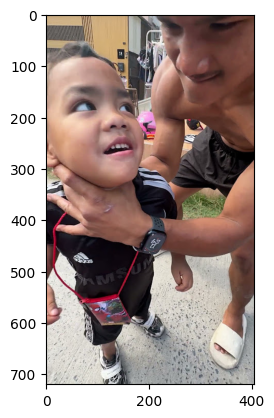

In [35]:
### START CODE HERE ###

path = './assets/oar2.jpg'
mpl_img = plt.imread(path)
plt.imshow(mpl_img)

### END CODE HERE ###

Normalize the image using the mean and standard deviation values from the [VGG16 normalization parameters.](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html)
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/2.png?raw=true)

</details>

/Users/bellian/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/bellian/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Input shape for VGG16: torch.Size([1, 3, 720, 405])
Normalized range: [-2.118, 2.640]


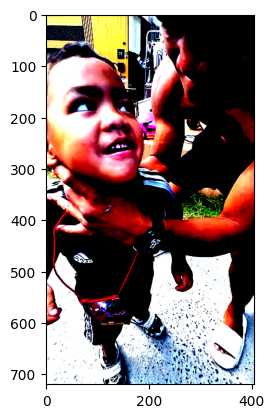

In [54]:
### START CODE HERE ###

torchvision.models.vgg16(pretrained=True).eval()
vgg16_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

normalized_img = vgg16_transform(mpl_img)

# Add batch dimension for VGG16
input_tensor = normalized_img.unsqueeze(0)

print(f"Input shape for VGG16: {input_tensor.shape}")
print(f"Normalized range: [{normalized_img.min():.3f}, {normalized_img.max():.3f}]")

np_normalized_img = input_tensor.squeeze().permute(1, 2, 0).numpy()

plt.imshow(np_normalized_img)

### END CODE HERE ###

Convert the [NumPy image to a PyTorch tensor](https://pytorch.org/docs/stable/torch.html#:~:text=memory%2Dmapped%20file.-,from_numpy,-Creates%20a%20Tensor), ensuring it has the [correct dimensions and data type](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html) for input to the first convolution layer.

In [55]:
### START CODE HERE ###

transform = transforms.Compose([
    transforms.ToTensor(),
])
normalized_img = transform(mpl_img)


### END CODE HERE ###

Complete the function below. <br>
The plot_featuremap function takes a set of feature maps and creates a grid of subplots, each displaying a single feature map. 

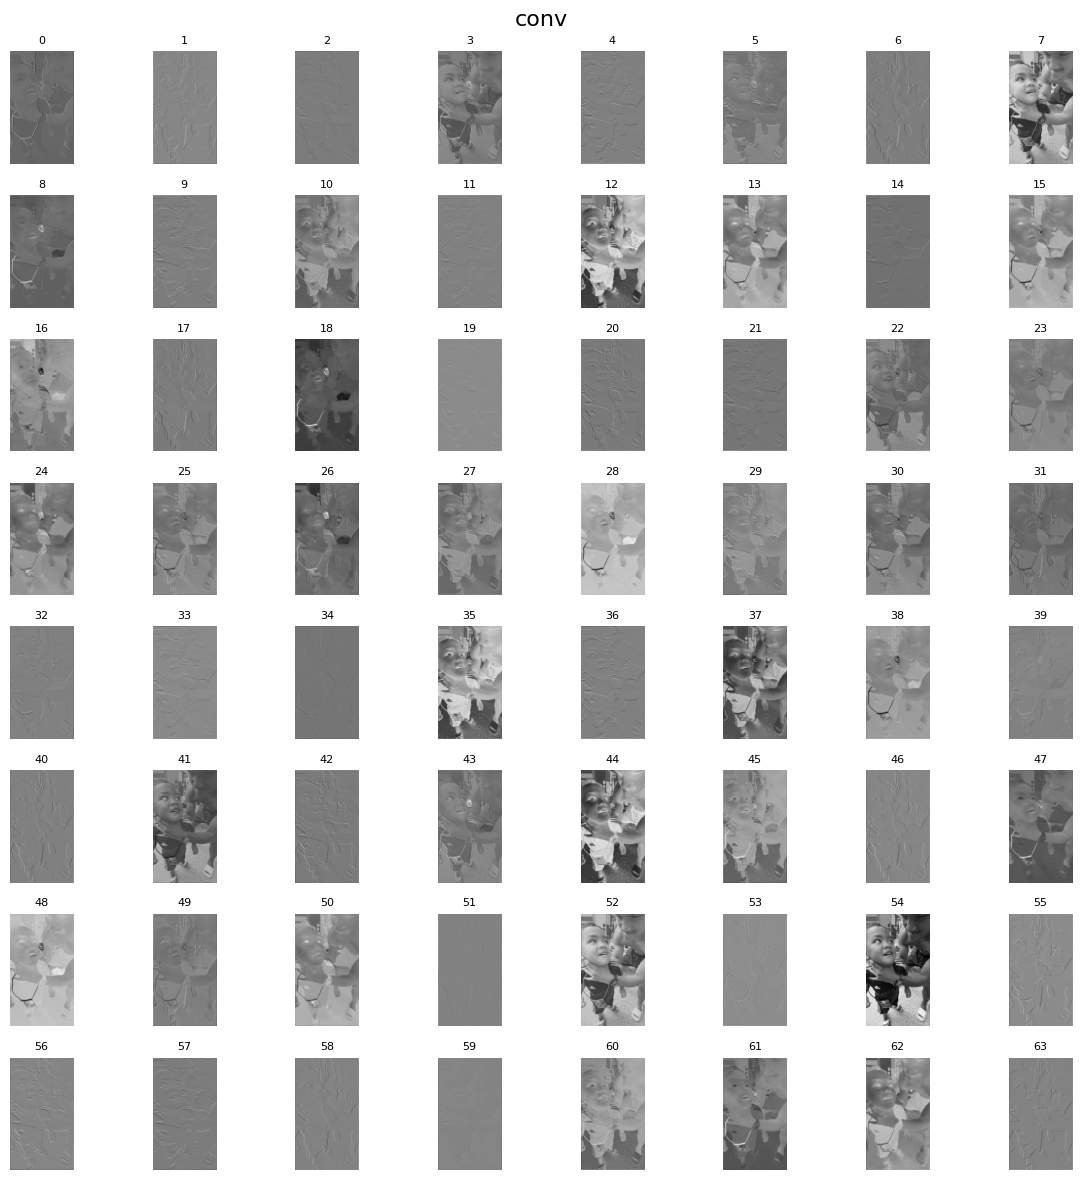

In [59]:
### START CODE HERE ###

def plot_featuremap(image, title):
    first_conv = vgg16.features[0]
    first_relu = vgg16.features[1]
    if title == "conv":
        with torch.no_grad():
            feature_maps = first_conv(image)
    elif title == "ReLU":
        with torch.no_grad():
            feature_maps = first_relu(first_conv(image))
    _, axs = plt.subplots(8, 8, figsize=(12, 12))
    axs = axs.flatten()
    for i in range(64):
        axs[i].imshow(feature_maps[0, i].detach().numpy(), cmap='gray')
        axs[i].axis('off')
        axs[i].set_title(f'{i}', fontsize=8)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Plot the 64 feature maps
plot_featuremap(normalized_img.unsqueeze(0), "conv")

### END CODE HERE ###

Pass the image to the first convolutional layer and display the feature map output using your `plot_featuremap()` function.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/3.png?raw=true)
</details>

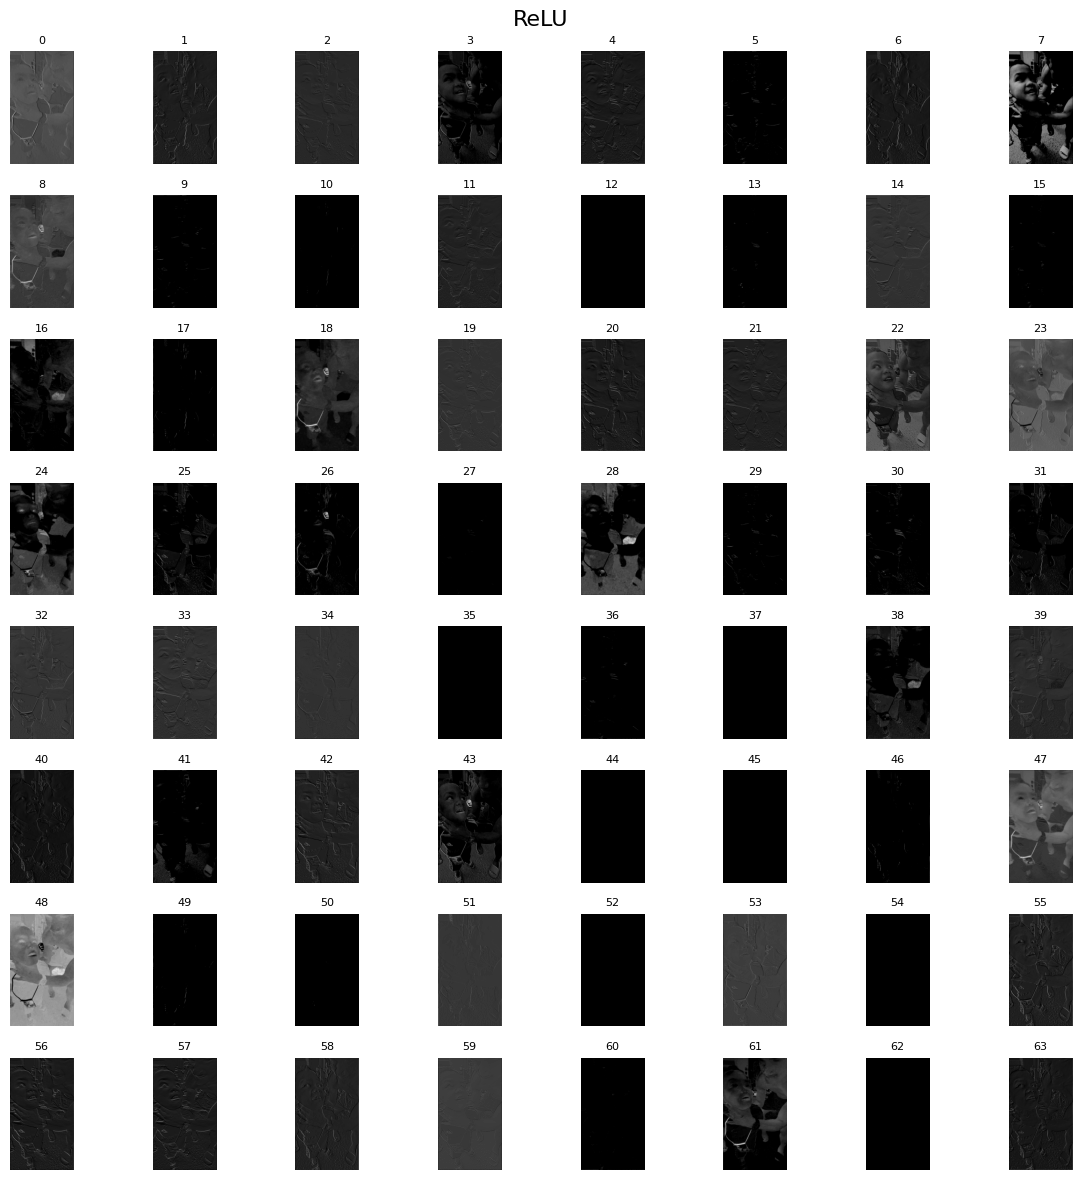

In [61]:
### START CODE HERE ###

plot_featuremap(normalized_img.unsqueeze(0), "ReLU")

### END CODE HERE ###

Pass the image to the first ReLU layer and display the feature map output using your `plot_featuremap()` function.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/4.png?raw=true)

</details>

In [ ]:
### START CODE HERE ###



### END CODE HERE ###

## Convolution 2D from scratch
Complete the function below

In [73]:
### START CODE HERE ###
### START CODE HERE ###
def convolution2d(img, kernel, padding, stride):
    # Get dimensions
    kernel_h, kernel_w = kernel.shape
    
    # Apply padding
    if padding > 0:
        padded_img = np.pad(img, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_img = img
    
    padded_h, padded_w = padded_img.shape
    
    # Calculate output dimensions
    output_h = (padded_h - kernel_h) // stride + 1
    output_w = (padded_w - kernel_w) // stride + 1
    
    # Initialize output
    output = np.zeros((output_h, output_w))
    
    # Perform convolution
    for i in range(0, output_h):
        for j in range(0, output_w):
            # Extract region of interest
            start_i = i * stride
            start_j = j * stride
            end_i = start_i + kernel_h
            end_j = start_j + kernel_w
            
            region = padded_img[start_i:end_i, start_j:end_j]
            
            # Element-wise multiplication and sum
            output[i, j] = np.sum(region * kernel)
    
    return output
### END CODE HERE ###

Copy the weights and biases from `vgg16` and then use each kernel perform a 2D convolution using `convolution2d` and display the resulting feature map
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/5.png?raw=true)

</details>

In [ ]:
### START CODE HERE ###

def plot_featuremap_2(image, title):
    img_np = image.squeeze().numpy()  # Shape: [3, H, W]
    feature_maps = []
    for kernel_idx in range(64):  # For each of the 64 kernels
        # Extract one kernel (3x3x3)
        kernel_3d = first_conv_weight[kernel_idx].numpy()  # Shape: [3, 3, 3]
        channel_outputs = []
        for channel_idx in range(3):  # For R, G, B channels
            # Get single channel image and kernel
            channel_img = img_np[channel_idx]  # Shape: [H, W]
            kernel_2d = kernel_3d[channel_idx]  # Shape: [3, 3]
            
            # Apply 2D convolution
            conv_output = convolution2d(channel_img, kernel_2d, padding=1, stride=1)
            channel_outputs.append(conv_output)
            if title == "ReLU":
                channel_outputs[-1] = np.maximum(0, channel_outputs[-1])
        # Sum outputs from all channels
        final_output = np.sum(channel_outputs, axis=0)
        feature_maps.append(final_output)
    
    # Plot the feature maps
    _, axs = plt.subplots(8, 8, figsize=(12, 12))
    axs = axs.flatten()
    for i in range(64):
        axs[i].imshow(feature_maps[i], cmap='gray')
        axs[i].axis('off')
        axs[i].set_title(f'{i}', fontsize=8)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

### END CODE HERE ###

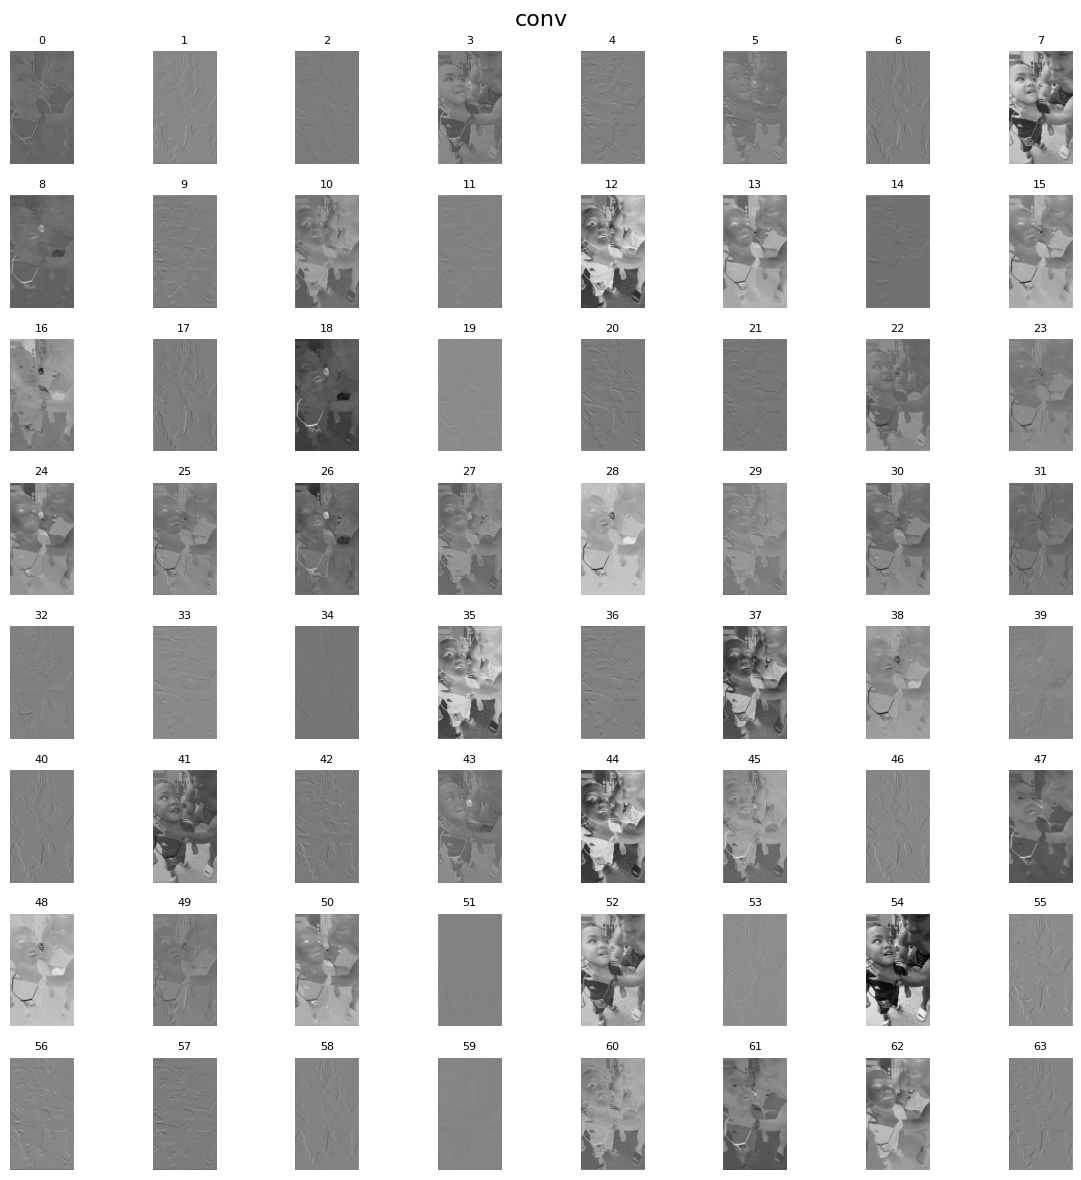

In [77]:
plot_featuremap_2(normalized_img.unsqueeze(0), "conv")

After performing the `convolution2d` operation, apply the ReLU activation function to the output. Then, display the resulting feature map.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/6.png?raw=true)

</details>

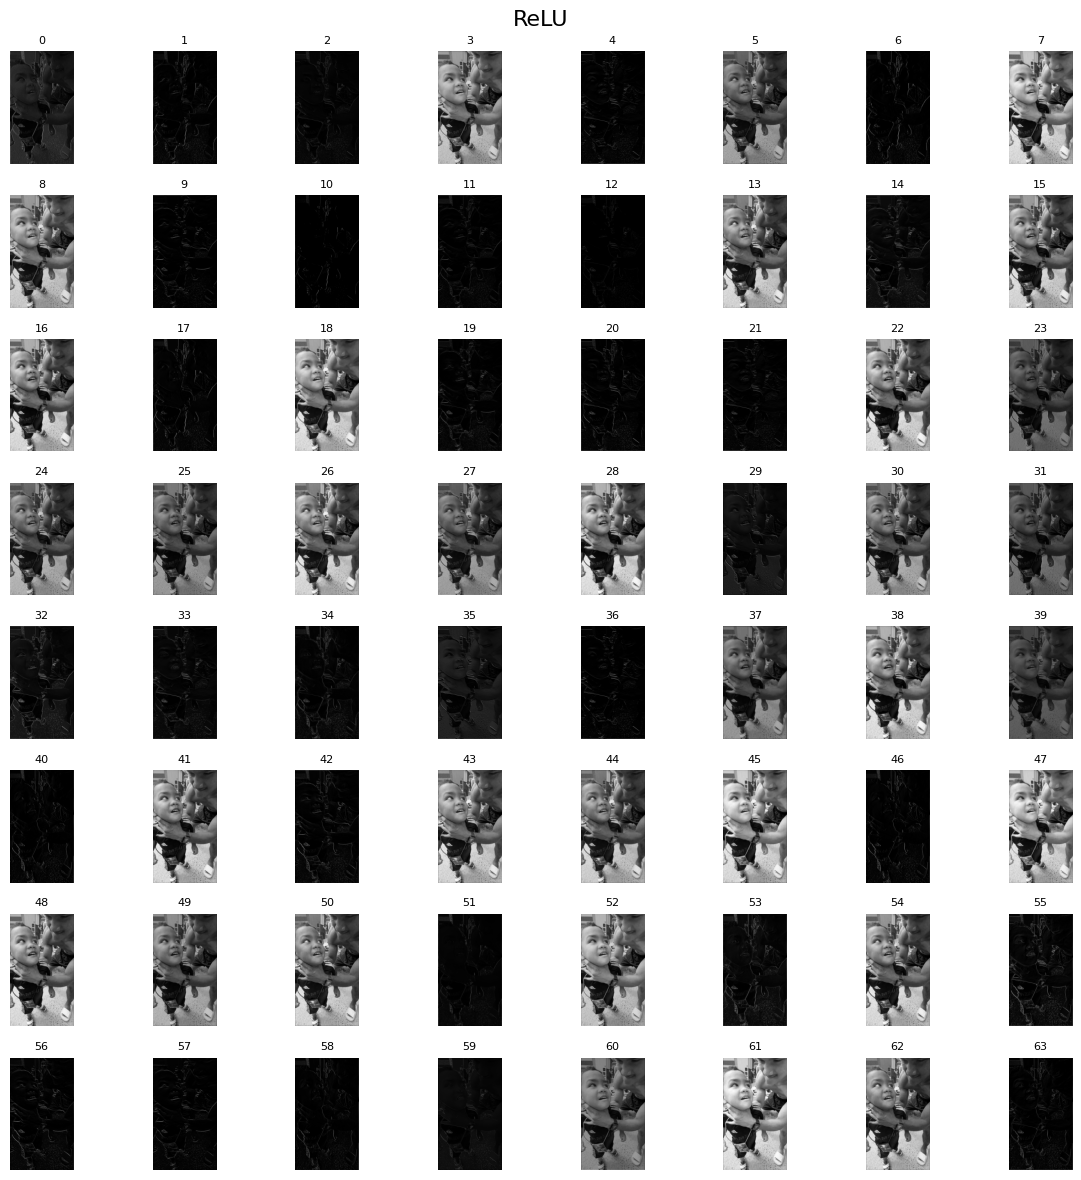

In [78]:
### START CODE HERE ###

plot_featuremap_2(normalized_img.unsqueeze(0), "ReLU")

### END CODE HERE ###

---

# Question
1. Show the array of kernel weights used for extracting object color 
and those used for extracting object edge details at least two CNN nodes.
Compare and Discuss how the specific values of these kernel weights influence the CNN's ability 
to detect colors versus edges in images.
2. Why is Matplotlib able to display the output feature map from the convolution layer, even though it contains negative values?
3. Is there a method faster than traditional 2D convolution in the "Convolution 2D from scratch" section?

In [82]:
for kernel_idx in range(first_conv_weight.shape[0]):  # Iterate through all 64 kernels
    if kernel_idx == 56 :
        print(f"Kernel : {kernel_idx}")
        print("*" * 37)
    
        for channel_idx in range(first_conv_weight.shape[1]):  # Iterate through 3 channels (RGB)
            print(f"Channel : {channel_idx}")
            kernel_channel = first_conv_weight[kernel_idx, channel_idx].numpy()
            print(kernel_channel)
            print(f"Min coefficients {kernel_channel.min()}")
            print("-" * 37)
    
        print()

Kernel : 56
*************************************
Channel : 0
[[ 0.06164433  0.01147503 -0.16980588]
 [ 0.12480544 -0.07662967 -0.2352681 ]
 [ 0.2332053   0.15032138 -0.11057352]]
Min coefficients -0.23526810109615326
-------------------------------------
Channel : 1
[[-0.19186816 -0.25780293 -0.35183543]
 [ 0.0566865  -0.08866787 -0.18990411]
 [ 0.41227737  0.45314243  0.20365058]]
Min coefficients -0.3518354296684265
-------------------------------------
Channel : 2
[[-0.21680391 -0.2806674  -0.36422443]
 [ 0.05863504 -0.05308631 -0.12098924]
 [ 0.34580755  0.39724928  0.23915227]]
Min coefficients -0.3642244338989258
-------------------------------------



In [83]:
for kernel_idx in range(first_conv_weight.shape[0]):  # Iterate through all 64 kernels
    if kernel_idx == 35 :
        print(f"Kernel : {kernel_idx}")
        print("*" * 37)
    
        for channel_idx in range(first_conv_weight.shape[1]):  # Iterate through 3 channels (RGB)
            print(f"Channel : {channel_idx}")
            kernel_channel = first_conv_weight[kernel_idx, channel_idx].numpy()
            print(kernel_channel)
            print(f"Min coefficients {kernel_channel.min()}")
            print("-" * 37)
    
        print()

Kernel : 35
*************************************
Channel : 0
[[ 0.12851088  0.04774099  0.11914468]
 [ 0.01547533 -0.08790586  0.10900504]
 [-0.09964113 -0.16575162  0.02831927]]
Min coefficients -0.1657516211271286
-------------------------------------
Channel : 1
[[ 0.06329037  0.05392476  0.15062654]
 [-0.07057341 -0.11096977  0.07283464]
 [-0.16453001 -0.23457824 -0.00692629]]
Min coefficients -0.2345782369375229
-------------------------------------
Channel : 2
[[-0.08700994 -0.14170869 -0.09579664]
 [-0.06930472 -0.13013494 -0.09098161]
 [-0.06040524 -0.11306594 -0.05184612]]
Min coefficients -0.14170868694782257
-------------------------------------



1. Kernel 56 - Edge Detection Kernel : High contrast values: Range from -0.36 to +0.45, Strong negative-to-positive transitions: Notice the pattern in channels 1 & 2 where top values are negative (-0.35, -0.36) and bottom values are positive (+0.45, +0.39)
   Kernel 35 - Color/Texture Detection Kernel : Smaller value range: Mostly between -0.23 to +0.15, Color variations: Subtle differences in RGB channels
2. Matplotlib automatically normalizes the data to the display range [0, 1] when using imshow()
3. Frequency Domain Convolution (FFT-based) : Performing convolution in the frequency domain using the Fast Fourier Transform (FFT). The computational complexity often reduces from O(N²K²) for direct convolution to O(N²log(N)) for FFT-based methods (where N is image size, K is kernel size).,
Spatially Separable Convolution